# Projects in data science: Decision Tree and Ensemble

## Exercise 1: Decision Tree
* Create a dataset with 2 features using the [make_classification function](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html) of scikit-learn. See a more detailed tutorial here: [How to Generate Datasets Using make_classification](https://proclusacademy.com/blog/sklearn_make_classification/)
* Train and evaluate a [Decision Tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) on the dataset
* Visualize the [decision boundary](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html)
* Use the [drawdata python library](https://github.com/koaning/drawdata) to create different datasets, train a decision tree, and look at the [tree structure](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html) and decision boundary

0.945273631840796


<Figure size 640x480 with 0 Axes>

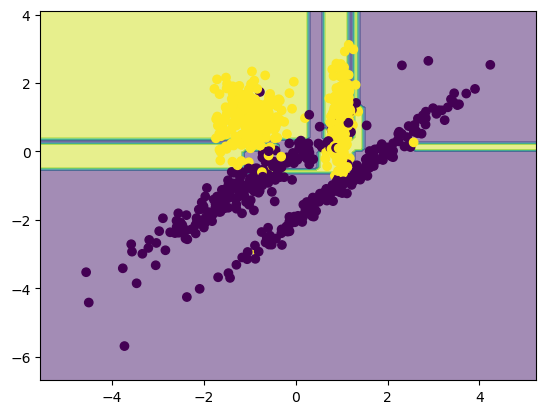

In [7]:
#Your answer
#Import libraries
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

#1
# Create a dataset
# your code here
x, y = make_classification(n_samples=1001, n_features=2, n_informative=2, n_redundant=0, random_state=999)

#Split into train and test
# your code here
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.2,stratify=y,random_state=999)

#2
#Create, fit and evaluate a Decision Tree 
# your code here
decision_tree = DecisionTreeClassifier(random_state=999)
decision_tree.fit(x_train,y_train)
print(decision_tree.score(x_val,y_val))

#3
#Plot model's decision boundary and test data
# your code here
plt.figure()
DecisionBoundaryDisplay.from_estimator(decision_tree,x_train,alpha=0.5)
plt.scatter(x_train[:,0],x_train[:,1],c=y_train)
plt.show()

### Question 1
#### What can you observe from this decision boundary?


### Question 2
#### What can you observe from the shape of this decision tree?

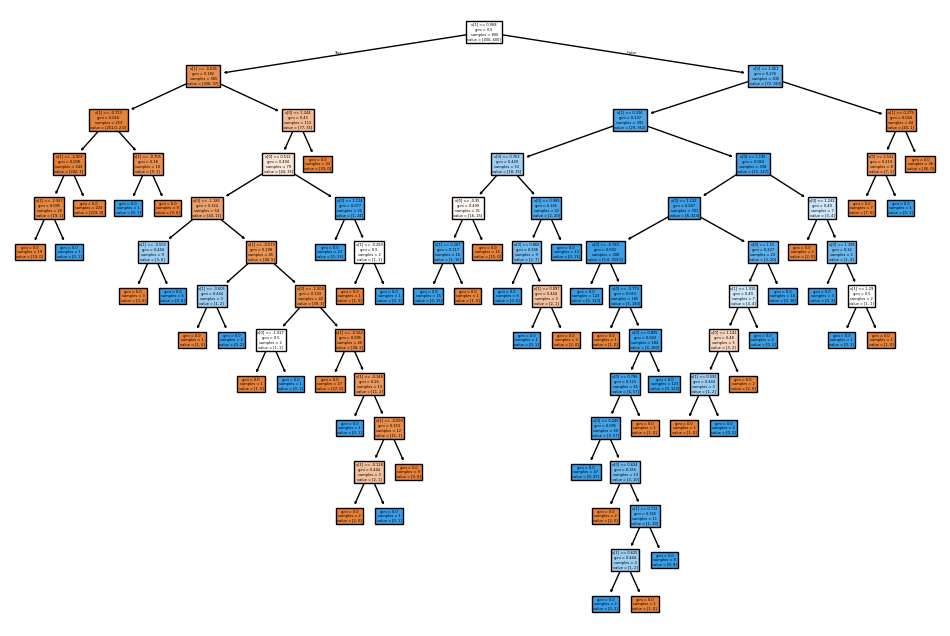

In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(decision_tree, filled=True) #filled=True colors the nodes according to the majority class
plt.show()

### drawdata widget

In [30]:
!pip install drawdata

Defaulting to user installation because normal site-packages is not writeable


In [32]:
from drawdata import ScatterWidget

widget = ScatterWidget()
widget

Train accuracy: 1.0
Validation accuracy: 1.0


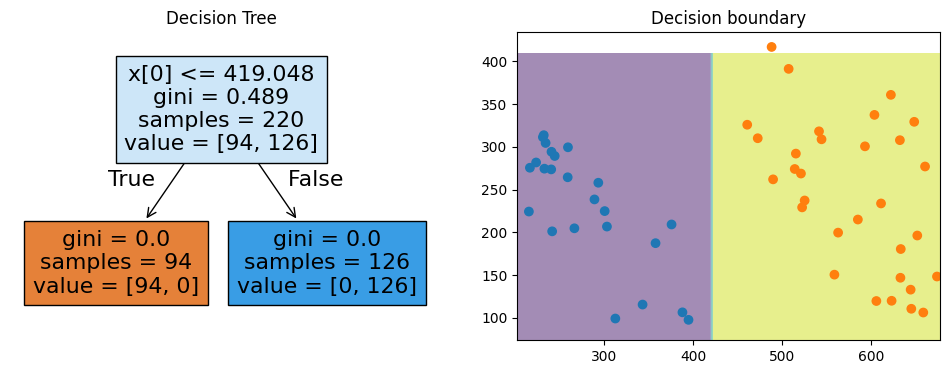

<Figure size 640x480 with 0 Axes>

In [ ]:
#Get the data from the drawdata widget
X, y = widget.data_as_X_y

#Split into train/test
x_train,x_val,y_train,y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=1907)

#2
#Create, fit and evaluate a Decision Tree 
# your code here

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

tree.plot_tree(decision_tree, filled=True, ax=ax[0])
ax[0].set_title("Decision Tree")

#Plot model's decision boundary and val data
plt.figure()
DecisionBoundaryDisplay.from_estimator(decision_tree,x_train,alpha=0.5, ax=ax[1])
ax[1].scatter(x_val[:,0],x_val[:,1],c=y_val)
ax[1].set_title("Decision boundary")
plt.show()


## Exercise 2: Random Forest
* Use sklearn or drawdata to get a dataset
* Train and evaluate [Random Forests](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) with different hyper-parameters (number of trees, maximum depth)
* Optionally, draw validation curves and think what hyperparameter you would choose

In [ ]:
#Create a dataset
x,y
#Split into train and test
x_train,x_val,y_train,y_val
n_est_metrics = {"train":[], "val":[]}

#Evaluate with different number of trees in the ensemble
print(f"Evaluating n_estimators:")

n_estimators = [1,5,10,50,100]
for n in n_estimators:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    rf.fit(x_train, y_train)
    
    train_score = rf.score(x_train, y_train)
    val_score = rf.score(x_val, y_val)
    
    n_est_metrics["train"].append(train_score)
    n_est_metrics["val"].append(val_score)
    
    print(f"n_estimators={n}: train={train_score:.3f}, val={val_score:.3f}")


#Evaluate with different maximum depth for trees
max_depth_metrics = {"train":[], "val":[]}

print(f"\nEvaluating max_depth:")
depths = [1,5,10,20,None]

for d in depths:
    rf = RandomForestClassifier(
        n_estimators=50,   # fixed number of trees
        max_depth=d,
        random_state=42
    )
    
    rf.fit(x_train, y_train)
    
    train_score = rf.score(x_train, y_train)
    val_score = rf.score(x_val, y_val)
    
    max_depth_metrics["train"].append(train_score)
    max_depth_metrics["val"].append(val_score)
    
    print(f"max_depth={d}: train={train_score:.3f}, val={val_score:.3f}")

Evaluating n_estimators:

Evaluating max_depth:


## Exercise 3 (bonus): Bagging and/or the Random Subspace Method
* Use the Decision Tree classifier from scikit learn and implement yourself the bagging method and/or the Random Subspace Method

### Bagging

In [ ]:
#Your answer
import random
import select
def train_bagging(x_train, y_train, n_estimators,number_of_selection):
    """
    params:
        - training_data: All training samples with both X (features) and y (groundtruth)
        - n_estimators: Number of tree in the ensemble
        - number_of_selection: Number of random selection with replacement to create the training dataset
    return:
        - An ensemble of Decision Tree each fitted with randomly selected data from X
    """
    # your code here

def eval_bagging(lst_classifier,x_val,y_val):
    """
    params:
        - lst_classifier: Ensemble to evaluate
        - X_val: features of the validation set
        - y_val: groundtruth of the validation set
    """
    # your code here

In [73]:
lst_classifier = train_bagging(x_train, y_train, 30, len(x_train))
eval_bagging(lst_classifier,x_val,y_val)

Accuracy of the ensemble: 0.61


**Your comments:**

### Random subspace method

In [ ]:
def train_RSM(x_train, y_train, n_estimators, number_of_selection):
    """
    params:
        - training_data: All training samples with both X (features) and y (groundtruth)
        - n_estimators: Number of tree in the ensemble
        - number_of_selection: Number of random selection of feature without replacement to create the training dataset
    return:
        - An ensemble of Decision Tree each fitted with randomly selected data from X
    """
    # your code here

def eval_RSM(lst_classifier, x_val, y_val):
    # your code here

In [78]:
lst_classifier = train_RSM(x_train, y_train, 30, x_train.shape[1])
eval_RSM(lst_classifier,x_val,y_val)

Accuracy of the ensemble: 0.575
